In [1]:
"""
Temporary filling-point cost assignment (Nigeria LPG chain, EPSG:3857)

This notebook applies a temporary simplification:
- all points in the `filling` layer receive `cost_kg = 0.6`

Important
---------
- this is an interim assumption only;
- filling-point cost will be computed with a more robust method later.
- the original merged GeoPackage is NOT modified;
  a reduced copied GeoPackage is created with only `resell` and `filling`.

Behavior
--------
1) verifies that the source GeoPackage exists,
2) creates/overwrites a reduced copied GeoPackage with only `resell` and `filling`,
3) validates required layers in the reduced copied file,
4) sets `cost_kg = 0.6` for all rows in `filling` using float dtype (no integer truncation).
"""

from __future__ import annotations

import sqlite3
import struct
from pathlib import Path

import geopandas as gpd
import pandas as pd

DATA_DIR = Path("dataset_big")
SOURCE_GPKG_PATH = DATA_DIR / "full_lpg_chain_nig_3857.gpkg"
OUTPUT_GPKG_PATH = DATA_DIR / "chain_with_cost.gpkg"

RESELL_LAYER = "resell"
FILLING_LAYER = "filling"
COST_COL = "cost_kg"
TEMP_FILLING_COST = 0.6


def _ensure_bytes(blob) -> bytes | None:
    if blob is None:
        return None
    if isinstance(blob, (bytes, bytearray)):
        return bytes(blob)
    if isinstance(blob, memoryview):
        return blob.tobytes()
    return None


def _gpkg_envelope_xy(geom_blob) -> tuple[float | None, float | None, float | None, float | None]:
    """Read minx/maxx/miny/maxy from GeoPackage geometry header envelope if present."""
    b = _ensure_bytes(geom_blob)
    if not b or len(b) < 8:
        return (None, None, None, None)

    # GeoPackageBinary header starts with magic 'GP'.
    if b[0:2] != b"GP":
        return (None, None, None, None)

    flags = b[3]
    envelope_code = (flags >> 1) & 0b111
    endian = "<" if (flags & 0b1) == 1 else ">"

    if envelope_code == 0:
        return (None, None, None, None)

    # Header layout: magic(2) + version(1) + flags(1) + srs_id(4) + envelope(...).
    offset = 8
    env_size_by_code = {1: 32, 2: 48, 3: 48, 4: 64}
    env_size = env_size_by_code.get(envelope_code, 0)
    if env_size == 0 or len(b) < offset + env_size:
        return (None, None, None, None)

    try:
        minx, maxx, miny, maxy = struct.unpack(endian + "4d", b[offset : offset + 32])
        return (float(minx), float(maxx), float(miny), float(maxy))
    except Exception:
        return (None, None, None, None)


def _sqlite_st_isempty(geom_blob):
    b = _ensure_bytes(geom_blob)
    return 1 if (b is None or len(b) == 0) else 0


def _sqlite_st_minx(geom_blob):
    return _gpkg_envelope_xy(geom_blob)[0]


def _sqlite_st_maxx(geom_blob):
    return _gpkg_envelope_xy(geom_blob)[1]


def _sqlite_st_miny(geom_blob):
    return _gpkg_envelope_xy(geom_blob)[2]


def _sqlite_st_maxy(geom_blob):
    return _gpkg_envelope_xy(geom_blob)[3]


def main() -> None:
    print("[1/4] Checking source GeoPackage...")
    if not SOURCE_GPKG_PATH.exists():
        raise FileNotFoundError(f"Source file not found: {SOURCE_GPKG_PATH}")

    print("[2/4] Creating reduced copied GeoPackage (only resell + filling)...")
    if OUTPUT_GPKG_PATH.exists():
        OUTPUT_GPKG_PATH.unlink()

    with sqlite3.connect(str(SOURCE_GPKG_PATH)) as conn:
        cur = conn.cursor()
        layers = cur.execute(
            "SELECT table_name FROM gpkg_contents WHERE data_type IN ('features', 'attributes')"
        ).fetchall()
        source_layer_names = {name for (name,) in layers}

    required_layers = {RESELL_LAYER, FILLING_LAYER}
    missing_source_layers = required_layers.difference(source_layer_names)
    if missing_source_layers:
        raise KeyError(
            f"Missing required source layer(s): {sorted(missing_source_layers)} in {SOURCE_GPKG_PATH}"
        )

    resell_src = gpd.read_file(SOURCE_GPKG_PATH, layer=RESELL_LAYER)
    filling_src = gpd.read_file(SOURCE_GPKG_PATH, layer=FILLING_LAYER)
    if resell_src.empty:
        raise RuntimeError(f"Layer '{RESELL_LAYER}' is empty in source file.")
    if filling_src.empty:
        raise RuntimeError(f"Layer '{FILLING_LAYER}' is empty in source file.")

    resell_src.to_file(OUTPUT_GPKG_PATH, layer=RESELL_LAYER, driver="GPKG")
    filling_src.to_file(OUTPUT_GPKG_PATH, layer=FILLING_LAYER, driver="GPKG")
    print(
        f"Created reduced copy: {OUTPUT_GPKG_PATH} | "
        f"resell={len(resell_src):,}, filling={len(filling_src):,}"
    )

    print("[3/4] Validating layers in reduced copied GeoPackage...")
    with sqlite3.connect(str(OUTPUT_GPKG_PATH)) as conn:
        cur = conn.cursor()
        layers = cur.execute(
            "SELECT table_name FROM gpkg_contents WHERE data_type IN ('features', 'attributes')"
        ).fetchall()
        layer_names = {name for (name,) in layers}
        if not layer_names:
            raise RuntimeError(f"No layers found in copied file: {OUTPUT_GPKG_PATH}")
        if FILLING_LAYER not in layer_names:
            raise KeyError(f"Required layer '{FILLING_LAYER}' not found in {OUTPUT_GPKG_PATH}")

    print("[4/4] Updating only filling points in copied file (float cost_kg)...")
    filling_out = gpd.read_file(OUTPUT_GPKG_PATH, layer=FILLING_LAYER)
    if filling_out.empty:
        raise RuntimeError(f"Layer '{FILLING_LAYER}' is empty in copied file.")

    filling_out[COST_COL] = float(TEMP_FILLING_COST)
    filling_out[COST_COL] = pd.to_numeric(filling_out[COST_COL], errors="coerce").astype(float)
    filling_out.to_file(OUTPUT_GPKG_PATH, layer=FILLING_LAYER, driver="GPKG")

    chk_n = int(len(filling_out))
    chk_min = float(filling_out[COST_COL].min())
    chk_max = float(filling_out[COST_COL].max())
    if chk_n == 0:
        raise RuntimeError(f"Layer '{FILLING_LAYER}' is empty in copied file.")
    if (abs(chk_min - float(TEMP_FILLING_COST)) > 1e-9) or (abs(chk_max - float(TEMP_FILLING_COST)) > 1e-9):
        raise RuntimeError(
            f"Unexpected filling cost values after update: min={chk_min}, max={chk_max}, expected={TEMP_FILLING_COST}"
        )

    print(f"Done. Updated {chk_n:,} rows in '{FILLING_LAYER}' in copied file only.")
    print(f"Source unchanged: {SOURCE_GPKG_PATH}")
    print(f"Output file:      {OUTPUT_GPKG_PATH}")


main()

[1/4] Checking source GeoPackage...
[2/4] Creating reduced copied GeoPackage (only resell + filling)...
Created reduced copy: dataset_big\chain_with_cost.gpkg | resell=2,416, filling=376
[3/4] Validating layers in reduced copied GeoPackage...
[4/4] Updating only filling points in copied file (float cost_kg)...
Done. Updated 376 rows in 'filling' in copied file only.
Source unchanged: dataset_big\full_lpg_chain_nig_3857.gpkg
Output file:      dataset_big\chain_with_cost.gpkg


In [2]:
"""
Assign one filling reference to each reseller using shortest-path travel time
on the motorized friction graph (Dijkstra), then write outputs to the copied GPKG.

Outputs:
- resell.filling_reference     (ID of assigned filling point; id_res&fil convention)
- resell.filling_ref_time_min  (shortest-path travel time in minutes)
- raster: filling_preferred_by_resell_id.tif
- raster: filling_preferred_by_resell_time_min.tif
"""

from __future__ import annotations

import sqlite3
import time
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from scipy.spatial import cKDTree

# ---------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------
DATA_DIR = Path("dataset_big")
WORK_GPKG = DATA_DIR / "chain_with_cost.gpkg"
RESELL_LAYER = "resell"
FILLING_LAYER = "filling"

MOTO_FRICTION_RASTER = DATA_DIR / "friction_moto.tif"
OUT_RASTER_FILL_ID = DATA_DIR / "filling_preferred_by_resell_id.tif"
OUT_RASTER_FILL_TIME = DATA_DIR / "filling_preferred_by_resell_time_min.tif"

ID_COL = "id_res&fil"
OUT_REF_COL = "filling_reference"
OUT_TIME_COL = "filling_ref_time_min"

CELL_SIZE_METERS = 1000.0
USE_8_NEIGHBORS = False
MIN_CANDIDATES = 3
PRIMARY_SEARCH_RADIUS_KM = 60
MAX_SEARCH_RADIUS_KM = 120
INITIAL_LIMIT_FACTOR = 10.0
FINAL_LIMIT_FACTOR = 16.0
LIMIT_MARGIN_MIN = 30.0
UNASSIGNED_TIME_MIN = 7000.0
NODATA_INT = -1
NODATA_FLOAT = -9999.0
PROGRESS_EVERY = 200

# ---------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------
def _read_friction(path: Path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32, copy=False)
        nodata = src.nodata
        profile = src.profile.copy()
    if nodata is not None:
        arr = np.where(arr == nodata, np.nan, arr).astype(np.float32)
    arr = np.where(arr > 0, arr, np.nan).astype(np.float32)
    return arr, profile


def _map_points_to_grid(gdf: gpd.GeoDataFrame, transform, width: int, height: int):
    rows, cols = rasterio.transform.rowcol(transform, gdf.geometry.x.values, gdf.geometry.y.values)
    rows = np.asarray(rows, dtype=np.int32)
    cols = np.asarray(cols, dtype=np.int32)
    inside = (rows >= 0) & (rows < height) & (cols >= 0) & (cols < width)
    return rows, cols, inside


def _candidate_idx_adaptive(r: int, c: int, tree: cKDTree, coords: np.ndarray) -> np.ndarray:
    idx = np.array([], dtype=np.int32)

    found_primary = tree.query_ball_point([r, c], r=PRIMARY_SEARCH_RADIUS_KM, p=2)
    if len(found_primary) > 0:
        idx = np.asarray(found_primary, dtype=np.int32)

    if idx.size < MIN_CANDIDATES:
        found_max = tree.query_ball_point([r, c], r=MAX_SEARCH_RADIUS_KM, p=2)
        if len(found_max) > 0:
            idx = np.unique(np.concatenate([idx, np.asarray(found_max, dtype=np.int32)]))

    if idx.size < MIN_CANDIDATES:
        k = min(max(MIN_CANDIDATES, 8), len(coords))
        _, nn = tree.query([r, c], k=k)
        idx = np.unique(np.concatenate([idx, np.atleast_1d(nn).astype(np.int32)]))

    return idx


def _pick_min_time(dist_row: np.ndarray, cand_idx: np.ndarray, fill_nodes: np.ndarray, fill_ids: np.ndarray):
    cand_nodes = fill_nodes[cand_idx]
    t = dist_row[cand_nodes]
    if not np.isfinite(t).any():
        return NODATA_INT, np.nan
    j = int(np.nanargmin(t))
    return int(fill_ids[cand_idx[j]]), float(t[j])


def _run_assign(
    src_node: int,
    r: int,
    c: int,
    graph: csr_matrix,
    friction_min: float,
    base_idx: np.ndarray,
    fill_rows: np.ndarray,
    fill_cols: np.ndarray,
    fill_nodes: np.ndarray,
    fill_ids: np.ndarray,
    src_component: int,
    fill_component: np.ndarray,
    ):
    cand = np.unique(base_idx)
    if cand.size > 0:
        cand = cand[fill_component[cand] == src_component]

    if cand.size == 0:
        return NODATA_INT, UNASSIGNED_TIME_MIN, "no_candidate_in_component"

    lb = np.hypot(fill_rows[cand] - r, fill_cols[cand] - c) * CELL_SIZE_METERS * max(friction_min, 1e-9)
    limit = float(np.nanmax(lb) * INITIAL_LIMIT_FACTOR + LIMIT_MARGIN_MIN) if lb.size > 0 else np.inf
    dist_row = dijkstra(
        csgraph=graph,
        directed=True,
        indices=[int(src_node)],
        unweighted=False,
        limit=limit,
    )[0]

    fid, tmin = _pick_min_time(dist_row, cand, fill_nodes, fill_ids)
    if fid >= 0 and np.isfinite(tmin):
        return fid, float(tmin), "base_ok"

    cand_global = np.where(fill_component == src_component)[0].astype(np.int32)
    if cand_global.size == 0:
        return NODATA_INT, UNASSIGNED_TIME_MIN, "no_global_in_component"

    lb2 = np.hypot(fill_rows[cand_global] - r, fill_cols[cand_global] - c) * CELL_SIZE_METERS * max(friction_min, 1e-9)
    limit2 = float(np.nanmax(lb2) * FINAL_LIMIT_FACTOR + LIMIT_MARGIN_MIN) if lb2.size > 0 else np.inf
    dist_row2 = dijkstra(
        csgraph=graph,
        directed=True,
        indices=[int(src_node)],
        unweighted=False,
        limit=limit2,
    )[0]

    fid2, tmin2 = _pick_min_time(dist_row2, cand_global, fill_nodes, fill_ids)
    if fid2 >= 0 and np.isfinite(tmin2):
        return fid2, float(tmin2), "fallback_ok"

    return NODATA_INT, UNASSIGNED_TIME_MIN, "fallback_unassigned"


def _write_int_raster(path: Path, array: np.ndarray, ref_profile: dict):
    profile = ref_profile.copy()
    profile.update(dtype="int32", count=1, nodata=NODATA_INT, compress="lzw")
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(array.astype(np.int32), 1)


def _write_float_raster(path: Path, array: np.ndarray, ref_profile: dict):
    profile = ref_profile.copy()
    profile.update(dtype="float32", count=1, nodata=NODATA_FLOAT, compress="lzw")
    out = np.where(np.isfinite(array), array, NODATA_FLOAT).astype(np.float32)
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(out, 1)


# ---------------------------------------------------------------------
# RUN
# ---------------------------------------------------------------------
t0 = time.time()
print("[1/7] Reading friction raster and building valid mask...")
friction, ref_profile = _read_friction(MOTO_FRICTION_RASTER)
height, width = friction.shape
transform = ref_profile["transform"]
crs = ref_profile["crs"]

valid = np.isfinite(friction)
if not np.any(valid):
    raise RuntimeError("No valid cells in motorized friction raster.")
friction_min = float(np.nanpercentile(friction[valid], 5))
print(f"Grid: {width} x {height} | valid cells: {int(valid.sum()):,}")

print("[2/7] Loading reseller and filling points from copied GeoPackage...")
resell = gpd.read_file(WORK_GPKG, layer=RESELL_LAYER)
filling = gpd.read_file(WORK_GPKG, layer=FILLING_LAYER)
if resell.empty:
    raise RuntimeError("Resell layer is empty.")
if filling.empty:
    raise RuntimeError("Filling layer is empty.")

for name, gdf in ((RESELL_LAYER, resell), (FILLING_LAYER, filling)):
    if ID_COL not in gdf.columns:
        raise KeyError(f"Missing '{ID_COL}' in layer '{name}'.")
    if gdf.geometry.isna().all():
        raise RuntimeError(f"All geometries are null in layer '{name}'.")

if resell.crs != crs:
    resell = resell.to_crs(crs)
if filling.crs != crs:
    filling = filling.to_crs(crs)

resell = resell[resell.geometry.notna() & resell.geometry.geom_type.isin(["Point"])].copy()
filling = filling[filling.geometry.notna() & filling.geometry.geom_type.isin(["Point"])].copy()

rid_resell = pd.to_numeric(resell[ID_COL], errors="coerce")
rid_fill = pd.to_numeric(filling[ID_COL], errors="coerce")
if rid_resell.isna().any() or (rid_resell <= 0).any() or (not rid_resell.is_unique):
    raise ValueError(f"Layer '{RESELL_LAYER}' must have unique positive numeric '{ID_COL}'.")
if rid_fill.isna().any() or (rid_fill <= 0).any() or (not rid_fill.is_unique):
    raise ValueError(f"Layer '{FILLING_LAYER}' must have unique positive numeric '{ID_COL}'.")

print("[3/7] Mapping points to friction grid...")
res_rows, res_cols, in_res = _map_points_to_grid(resell, transform, width, height)
fill_rows, fill_cols, in_fill = _map_points_to_grid(filling, transform, width, height)

resell = resell.loc[in_res].copy()
filling = filling.loc[in_fill].copy()
res_rows = res_rows[in_res]
res_cols = res_cols[in_res]
fill_rows = fill_rows[in_fill]
fill_cols = fill_cols[in_fill]
rid_resell = rid_resell.loc[in_res].astype(np.int32).to_numpy()
rid_fill = rid_fill.loc[in_fill].astype(np.int32).to_numpy()

if len(resell) == 0 or len(filling) == 0:
    raise RuntimeError("No points left inside raster extent after mapping.")

print(f"Resellers on grid: {len(resell):,}")
print(f"Fillings on grid : {len(filling):,}")

print("[4/7] Building shortest-path graph on friction_moto...")
node_id = -np.ones((height, width), dtype=np.int32)
vr, vc = np.where(valid)
node_id[vr, vc] = np.arange(len(vr), dtype=np.int32)
n_nodes = len(vr)

if USE_8_NEIGHBORS:
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]
else:
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]

edge_i = []
edge_j = []
edge_c = []
diag_factor = np.sqrt(2.0)

for r, c in zip(vr, vc):
    n0 = node_id[r, c]
    f0 = friction[r, c]
    for dr, dc in neighbors:
        rr = r + dr
        cc = c + dc
        if rr < 0 or rr >= height or cc < 0 or cc >= width:
            continue
        n1 = node_id[rr, cc]
        if n1 < 0:
            continue
        f1 = friction[rr, cc]
        if not np.isfinite(f1):
            continue

        step_m = CELL_SIZE_METERS
        if dr != 0 and dc != 0:
            step_m *= diag_factor

        cost = 0.5 * (f0 + f1) * step_m
        if cost <= 0:
            continue

        edge_i.append(int(n0))
        edge_j.append(int(n1))
        edge_c.append(float(cost))

graph = csr_matrix((edge_c, (edge_i, edge_j)), shape=(n_nodes, n_nodes))
n_comp, comp = connected_components(csgraph=graph, directed=False, return_labels=True)
print(f"Graph nodes: {n_nodes:,} | edges: {len(edge_i):,} | components: {n_comp:,}")

res_nodes = node_id[res_rows, res_cols]
fill_nodes = node_id[fill_rows, fill_cols]

ok_res = res_nodes >= 0
ok_fill = fill_nodes >= 0
res_nodes = res_nodes[ok_res]
res_rows = res_rows[ok_res]
res_cols = res_cols[ok_res]
rid_resell = rid_resell[ok_res]

fill_nodes = fill_nodes[ok_fill]
fill_rows = fill_rows[ok_fill]
fill_cols = fill_cols[ok_fill]
rid_fill = rid_fill[ok_fill]

if len(res_nodes) == 0 or len(fill_nodes) == 0:
    raise RuntimeError("No reseller/filling mapped to valid graph nodes.")

fill_comp = comp[fill_nodes]
fill_tree = cKDTree(np.column_stack([fill_rows, fill_cols]).astype(np.float64))

print("[5/7] Assigning nearest filling per reseller (Dijkstra + adaptive candidates)...")
n_res = len(res_nodes)
ref_id = np.full(n_res, NODATA_INT, dtype=np.int32)
ref_time = np.full(n_res, UNASSIGNED_TIME_MIN, dtype=np.float32)
reasons = {}
loop_t0 = time.time()

for k, (src_node, r, c) in enumerate(zip(res_nodes, res_rows, res_cols), start=1):
    base_idx = _candidate_idx_adaptive(int(r), int(c), fill_tree, fill_tree.data)
    src_comp = int(comp[int(src_node)])
    fid, tmin, reason = _run_assign(
        src_node=int(src_node),
        r=int(r),
        c=int(c),
        graph=graph,
        friction_min=friction_min,
        base_idx=base_idx,
        fill_rows=fill_rows,
        fill_cols=fill_cols,
        fill_nodes=fill_nodes,
        fill_ids=rid_fill,
        src_component=src_comp,
        fill_component=fill_comp,
    )
    ref_id[k - 1] = int(fid)
    ref_time[k - 1] = float(tmin)
    reasons[reason] = int(reasons.get(reason, 0)) + 1

    if (k % PROGRESS_EVERY == 0) or (k == n_res):
        elapsed = time.time() - loop_t0
        speed = k / max(elapsed, 1e-9)
        rem = (n_res - k) / max(speed, 1e-9)
        print(f"  {k:,}/{n_res:,} ({100.0*k/n_res:.1f}%) | {speed:.1f} res/s | ETA ~{rem/60:.1f} min")

assigned_ok = (ref_id >= 0) & np.isfinite(ref_time) & (ref_time < UNASSIGNED_TIME_MIN)
print(f"Assigned resellers: {int(assigned_ok.sum()):,}/{n_res:,}")
print("Reason counts:", reasons)

def _register_gpkg_sql_functions(conn):
    # Reuse spatial fallback helpers defined in Cell 1.
    required = [
        "_sqlite_st_isempty",
        "_sqlite_st_minx",
        "_sqlite_st_maxx",
        "_sqlite_st_miny",
        "_sqlite_st_maxy",
    ]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError(
            "Missing GeoPackage SQL helper(s). Run Cell 1 first. Missing: " + ", ".join(missing)
        )
    conn.create_function("ST_IsEmpty", 1, globals()["_sqlite_st_isempty"])
    conn.create_function("ST_MinX", 1, globals()["_sqlite_st_minx"])
    conn.create_function("ST_MaxX", 1, globals()["_sqlite_st_maxx"])
    conn.create_function("ST_MinY", 1, globals()["_sqlite_st_miny"])
    conn.create_function("ST_MaxY", 1, globals()["_sqlite_st_maxy"])

print("[6/7] Updating reseller table in copied GeoPackage...")
updates = pd.DataFrame({
    ID_COL: rid_resell,
    OUT_REF_COL: ref_id,
    OUT_TIME_COL: ref_time,
})

with sqlite3.connect(str(WORK_GPKG)) as conn:
    _register_gpkg_sql_functions(conn)
    cur = conn.cursor()
    cols = [c[1] for c in cur.execute(f'PRAGMA table_info("{RESELL_LAYER}")').fetchall()]
    if OUT_REF_COL not in cols:
        cur.execute(f'ALTER TABLE "{RESELL_LAYER}" ADD COLUMN "{OUT_REF_COL}" INTEGER')
    if OUT_TIME_COL not in cols:
        cur.execute(f'ALTER TABLE "{RESELL_LAYER}" ADD COLUMN "{OUT_TIME_COL}" REAL')

    # Reset all rows first: avoids stale values for points outside graph/raster mapping.
    cur.execute(
        f'UPDATE "{RESELL_LAYER}" SET "{OUT_REF_COL}" = ?, "{OUT_TIME_COL}" = ?',
        (int(NODATA_INT), float(UNASSIGNED_TIME_MIN)),
    )

    cur.executemany(
        f'UPDATE "{RESELL_LAYER}" SET "{OUT_REF_COL}" = ?, "{OUT_TIME_COL}" = ? WHERE "{ID_COL}" = ?',
        [
            (int(a), float(t), int(rid))
            for a, t, rid in zip(
                updates[OUT_REF_COL].to_numpy(),
                updates[OUT_TIME_COL].to_numpy(),
                updates[ID_COL].to_numpy(),
            )
        ],
    )
    conn.commit()

print("[7/7] Writing visual rasters for QA...")
rast_id = np.full((height, width), NODATA_INT, dtype=np.int32)
rast_time = np.full((height, width), np.nan, dtype=np.float32)

for r, c, a, t in zip(res_rows, res_cols, ref_id, ref_time):
    rast_id[r, c] = int(a)
    rast_time[r, c] = float(t)

_write_int_raster(OUT_RASTER_FILL_ID, rast_id, ref_profile)
_write_float_raster(OUT_RASTER_FILL_TIME, rast_time, ref_profile)

print(f"Updated layer: {WORK_GPKG} | {RESELL_LAYER}")
print(f"- Column added/updated: {OUT_REF_COL}")
print(f"- Column added/updated: {OUT_TIME_COL}")
print(f"Raster ID   : {OUT_RASTER_FILL_ID}")
print(f"Raster time : {OUT_RASTER_FILL_TIME}")
print(f"Done in {(time.time() - t0)/60:.1f} min")

[1/7] Reading friction raster and building valid mask...
Grid: 1442 x 1156 | valid cells: 1,078,258
[2/7] Loading reseller and filling points from copied GeoPackage...
[3/7] Mapping points to friction grid...
Resellers on grid: 2,416
Fillings on grid : 376
[4/7] Building shortest-path graph on friction_moto...
Graph nodes: 1,078,258 | edges: 4,302,586 | components: 20
[5/7] Assigning nearest filling per reseller (Dijkstra + adaptive candidates)...
  200/2,413 (8.3%) | 8.0 res/s | ETA ~4.6 min
  400/2,413 (16.6%) | 10.2 res/s | ETA ~3.3 min
  600/2,413 (24.9%) | 10.7 res/s | ETA ~2.8 min
  800/2,413 (33.2%) | 10.7 res/s | ETA ~2.5 min
  1,000/2,413 (41.4%) | 10.7 res/s | ETA ~2.2 min
  1,200/2,413 (49.7%) | 10.1 res/s | ETA ~2.0 min
  1,400/2,413 (58.0%) | 10.2 res/s | ETA ~1.7 min
  1,600/2,413 (66.3%) | 9.5 res/s | ETA ~1.4 min
  1,800/2,413 (74.6%) | 9.4 res/s | ETA ~1.1 min
  2,000/2,413 (82.9%) | 9.9 res/s | ETA ~0.7 min
  2,200/2,413 (91.2%) | 10.1 res/s | ETA ~0.4 min
  2,400/2,4

In [10]:
"""
Update reseller cost_kg using assigned filling reference.

Formula agreed:
    cost_kg_resell = cost_kg_filling_reference + filling_ref_time_min / 1000
"""

from __future__ import annotations

from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd

DATA_DIR = Path("dataset_big")
WORK_GPKG = DATA_DIR / "chain_with_cost.gpkg"

RESELL_LAYER = "resell"
FILLING_LAYER = "filling"
ID_COL = "id_res&fil"
FILL_REF_COL = "filling_reference"
FILL_TIME_COL = "filling_ref_time_min"
COST_COL = "cost_kg"
FILL_ORIGIN_COST_COL = "filling_origin_cost"

print("[1/4] Loading reseller and filling layers from copied GeoPackage...")
resell = gpd.read_file(WORK_GPKG, layer=RESELL_LAYER)
filling = gpd.read_file(WORK_GPKG, layer=FILLING_LAYER)

if resell.empty:
    raise RuntimeError(f"Layer '{RESELL_LAYER}' is empty.")
if filling.empty:
    raise RuntimeError(f"Layer '{FILLING_LAYER}' is empty.")

for c in [ID_COL, FILL_REF_COL, FILL_TIME_COL]:
    if c not in resell.columns:
        raise KeyError(f"Missing column '{c}' in layer '{RESELL_LAYER}'.")
for c in [ID_COL, COST_COL]:
    if c not in filling.columns:
        raise KeyError(f"Missing column '{c}' in layer '{FILLING_LAYER}'.")

print("[2/4] Validating data and computing new reseller cost_kg...")
rid = pd.to_numeric(resell[ID_COL], errors="coerce")
fref = pd.to_numeric(resell[FILL_REF_COL], errors="coerce")
tmin = pd.to_numeric(resell[FILL_TIME_COL], errors="coerce")

fid = pd.to_numeric(filling[ID_COL], errors="coerce")
fcost = pd.to_numeric(filling[COST_COL], errors="coerce")

if rid.isna().any() or (rid <= 0).any() or (not rid.is_unique):
    raise ValueError(f"Layer '{RESELL_LAYER}' has invalid '{ID_COL}' values.")
if fid.isna().any() or (fid <= 0).any() or (not fid.is_unique):
    raise ValueError(f"Layer '{FILLING_LAYER}' has invalid '{ID_COL}' values.")

map_filling_cost = dict(zip(fid.astype(np.int64), fcost.astype(float)))
fill_cost = fref.map(map_filling_cost)

valid = (
    fref.notna()
    & tmin.notna()
    & fill_cost.notna()
    & (fref > 0)
    & np.isfinite(tmin)
    & np.isfinite(fill_cost)
    & (tmin >= 0)
    & (tmin < 7000)
    & (fill_cost >= 0)
)

new_cost = np.where(
    valid,
    fill_cost + (tmin / 1000.0),
    np.nan,
)

n_valid = int(valid.sum())
n_total = int(len(resell))
if n_valid == 0:
    raise RuntimeError("No valid reseller rows found for cost update.")

print("[3/4] Writing updated columns to reseller layer...")
# Keep only meaningful derived columns in final output.
resell[FILL_ORIGIN_COST_COL] = pd.to_numeric(fill_cost, errors="coerce").astype(float)
resell[COST_COL] = np.nan
resell.loc[valid, COST_COL] = pd.to_numeric(pd.Series(new_cost, index=resell.index)[valid], errors="coerce").astype(float)
resell[COST_COL] = pd.to_numeric(resell[COST_COL], errors="coerce").astype(float)

# Remove legacy temporary helper columns if they exist from previous runs.
for tmp_col in ["rid", "fref", "tmin", "fill_cost", "new_cost"]:
    if tmp_col in resell.columns:
        resell = resell.drop(columns=[tmp_col])

resell = gpd.GeoDataFrame(resell, geometry="geometry", crs=resell.crs)
resell.to_file(WORK_GPKG, layer=RESELL_LAYER, driver="GPKG")

print("[4/4] Done.")
print(f"Updated rows: {n_valid:,}/{n_total:,} in layer '{RESELL_LAYER}'")
print(f"Output file: {WORK_GPKG}")
print("Formula used: cost_kg_resell = cost_kg_filling + filling_ref_time_min / 1000")
print(
    "Sanity (valid rows) min/median/mean/p95/max: "
    f"{float(np.nanmin(resell.loc[valid, COST_COL])):.4f} / "
    f"{float(np.nanmedian(resell.loc[valid, COST_COL])):.4f} / "
    f"{float(np.nanmean(resell.loc[valid, COST_COL])):.4f} / "
    f"{float(np.nanpercentile(resell.loc[valid, COST_COL], 95)):.4f} / "
    f"{float(np.nanmax(resell.loc[valid, COST_COL])):.4f}"
)
print(f"Kept helper column: {FILL_ORIGIN_COST_COL}")

[1/4] Loading reseller and filling layers from copied GeoPackage...
[2/4] Validating data and computing new reseller cost_kg...
[3/4] Writing updated columns to reseller layer...
[4/4] Done.
Updated rows: 2,413/2,416 in layer 'resell'
Output file: dataset_big\chain_with_cost.gpkg
Formula used: cost_kg_resell = cost_kg_filling + filling_ref_time_min / 1000
Sanity (valid rows) min/median/mean/p95/max: 0.6000 / 0.6040 / 0.6193 / 0.6818 / 1.6879
Kept helper column: filling_origin_cost


In [11]:
"""
Final QA stats for 4.4 outputs.

Checks:
1) filling points have updated cost_kg (not legacy 999) and sensible values
2) resell points have a valid filling_reference and sensible travel stats
3) resell points have updated cost_kg (not legacy 999) and sensible values
"""

from __future__ import annotations

from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd

DATA_DIR = Path("dataset_big")
WORK_GPKG = DATA_DIR / "chain_with_cost.gpkg"

RESELL_LAYER = "resell"
FILLING_LAYER = "filling"
ID_COL = "id_res&fil"
COST_COL = "cost_kg"
FILL_REF_COL = "filling_reference"
FILL_TIME_COL = "filling_ref_time_min"

print("[1/4] Loading layers...")
resell = gpd.read_file(WORK_GPKG, layer=RESELL_LAYER)
filling = gpd.read_file(WORK_GPKG, layer=FILLING_LAYER)
if resell.empty or filling.empty:
    raise RuntimeError("Resell or filling layer is empty in chain_with_cost.gpkg")

for layer_name, gdf in ((RESELL_LAYER, resell), (FILLING_LAYER, filling)):
    for c in [ID_COL, COST_COL]:
        if c not in gdf.columns:
            raise KeyError(f"Missing column '{c}' in layer '{layer_name}'")
if FILL_REF_COL not in resell.columns:
    raise KeyError(f"Missing column '{FILL_REF_COL}' in layer '{RESELL_LAYER}'")
if FILL_TIME_COL not in resell.columns:
    raise KeyError(f"Missing column '{FILL_TIME_COL}' in layer '{RESELL_LAYER}'")

fill_id = pd.to_numeric(filling[ID_COL], errors="coerce")
fill_cost = pd.to_numeric(filling[COST_COL], errors="coerce")
res_id = pd.to_numeric(resell[ID_COL], errors="coerce")
res_ref = pd.to_numeric(resell[FILL_REF_COL], errors="coerce")
res_tmin = pd.to_numeric(resell[FILL_TIME_COL], errors="coerce")
res_cost = pd.to_numeric(resell[COST_COL], errors="coerce")

print("[2/4] QA on filling cost_kg...")
n_fill = len(filling)
fill_valid = np.isfinite(fill_cost)
fill_not_999 = fill_valid & (~np.isclose(fill_cost, 999.0))
fill_nonneg = fill_valid & (fill_cost >= 0)

print("=== FILLING COST QA ===")
print(f"Filling points total         : {n_fill:,}")
print(f"Finite cost_kg               : {int(fill_valid.sum()):,}")
print(f"cost_kg != 999               : {int(fill_not_999.sum()):,}")
print(f"cost_kg == 999 (legacy)      : {int((fill_valid & np.isclose(fill_cost, 999.0)).sum()):,}")
print(f"cost_kg < 0                  : {int((fill_valid & (fill_cost < 0)).sum()):,}")
if fill_valid.any():
    print(
        "cost_kg min/median/mean/max : "
        f"{float(np.nanmin(fill_cost)):.4f} / {float(np.nanmedian(fill_cost)):.4f} / "
        f"{float(np.nanmean(fill_cost)):.4f} / {float(np.nanmax(fill_cost)):.4f}"
    )

print("\n[3/4] QA on reseller filling reference and travel stats...")
n_res = len(resell)
fill_id_set = set(fill_id[np.isfinite(fill_id)].astype(np.int64).tolist())
ref_finite = np.isfinite(res_ref)
ref_positive = ref_finite & (res_ref > 0)
ref_exists = ref_positive & pd.Series(res_ref.astype("Int64")).isin(fill_id_set).to_numpy()

time_valid = np.isfinite(res_tmin) & (res_tmin >= 0) & (res_tmin < 7000)
ref_and_time_valid = ref_exists & time_valid

print("=== RESELLER REFERENCE QA ===")
print(f"Resell points total                    : {n_res:,}")
print(f"Resell with finite filling_reference   : {int(ref_finite.sum()):,}")
print(f"Resell with existing filling_reference : {int(ref_exists.sum()):,}")
print(f"Resell with valid reference + time     : {int(ref_and_time_valid.sum()):,}")
print(f"Missing/invalid reference              : {int((~ref_exists).sum()):,}")
if ref_and_time_valid.any():
    t = res_tmin[ref_and_time_valid].to_numpy(dtype=float)
    print(
        "Travel time min/median/mean/p95/max (min): "
        f"{float(np.nanmin(t)):.2f} / {float(np.nanmedian(t)):.2f} / {float(np.nanmean(t)):.2f} / "
        f"{float(np.nanpercentile(t, 95)):.2f} / {float(np.nanmax(t)):.2f}"
    )

# Optional geometric sanity check in km (straight-line)
if (resell.crs is not None) and (filling.crs is not None) and (str(resell.crs) == str(filling.crs)):
    fill_geom = filling[[ID_COL, "geometry"]].copy()
    fill_geom[ID_COL] = pd.to_numeric(fill_geom[ID_COL], errors="coerce")
    merged = resell[[ID_COL, FILL_REF_COL, "geometry"]].copy()
    merged[ID_COL] = pd.to_numeric(merged[ID_COL], errors="coerce")
    merged[FILL_REF_COL] = pd.to_numeric(merged[FILL_REF_COL], errors="coerce")
    merged = merged.merge(fill_geom, left_on=FILL_REF_COL, right_on=ID_COL, how="left", suffixes=("_res", "_fill"))
    good_geom = merged["geometry_res"].notna() & merged["geometry_fill"].notna()
    if good_geom.any():
        dist_km = merged.loc[good_geom, "geometry_res"].distance(merged.loc[good_geom, "geometry_fill"]).astype(float) / 1000.0
        print(
            "Straight-line distance min/median/mean/p95/max (km): "
            f"{float(np.nanmin(dist_km)):.2f} / {float(np.nanmedian(dist_km)):.2f} / {float(np.nanmean(dist_km)):.2f} / "
            f"{float(np.nanpercentile(dist_km, 95)):.2f} / {float(np.nanmax(dist_km)):.2f}"
        )

print("\n[4/4] QA on reseller cost_kg...")
res_cost_valid = np.isfinite(res_cost)
res_cost_not_999 = res_cost_valid & (~np.isclose(res_cost, 999.0))
res_cost_nonneg = res_cost_valid & (res_cost >= 0)
res_cost_updated_and_linked = res_cost_not_999 & ref_and_time_valid

print("=== RESELLER COST QA ===")
print(f"Finite cost_kg                        : {int(res_cost_valid.sum()):,}/{n_res:,}")
print(f"cost_kg != 999                        : {int(res_cost_not_999.sum()):,}/{n_res:,}")
print(f"cost_kg updated with valid reference  : {int(res_cost_updated_and_linked.sum()):,}/{n_res:,}")
print(f"cost_kg == 999 (legacy)               : {int((res_cost_valid & np.isclose(res_cost, 999.0)).sum()):,}")
print(f"cost_kg < 0                           : {int((res_cost_valid & (res_cost < 0)).sum()):,}")
if res_cost_valid.any():
    print(
        "cost_kg min/median/mean/p95/max      : "
        f"{float(np.nanmin(res_cost)):.4f} / {float(np.nanmedian(res_cost)):.4f} / {float(np.nanmean(res_cost)):.4f} / "
        f"{float(np.nanpercentile(res_cost, 95)):.4f} / {float(np.nanmax(res_cost)):.4f}"
    )

print("\nQA completed.")

[1/4] Loading layers...
[2/4] QA on filling cost_kg...
=== FILLING COST QA ===
Filling points total         : 376
Finite cost_kg               : 376
cost_kg != 999               : 376
cost_kg == 999 (legacy)      : 0
cost_kg < 0                  : 0
cost_kg min/median/mean/max : 0.6000 / 0.6000 / 0.6000 / 0.6000

[3/4] QA on reseller filling reference and travel stats...
=== RESELLER REFERENCE QA ===
Resell points total                    : 2,416
Resell with finite filling_reference   : 2,416
Resell with existing filling_reference : 2,413
Resell with valid reference + time     : 2,413
Missing/invalid reference              : 3
Travel time min/median/mean/p95/max (min): 0.00 / 4.00 / 19.28 / 81.84 / 1087.94
Straight-line distance min/median/mean/p95/max (km): 0.00 / 3.86 / 16.95 / 74.58 / 262.74

[4/4] QA on reseller cost_kg...
=== RESELLER COST QA ===
Finite cost_kg                        : 2,413/2,416
cost_kg != 999                        : 2,413/2,416
cost_kg updated with valid refer

[1/4] Loading reseller/filling layers...
[2/4] Building validity flags...
=== ASSIGNMENT COVERAGE ===
Total resellers                      : 2,416
Valid assigned resellers             : 2,413
Assignment coverage                  : 99.88%
Missing/invalid filling reference    : 3
Invalid/unassigned travel time       : 3
[3/4] Computing distributions...
=== TRAVEL TIME STATS (min) ===
min / p50 / p90 / p95 / p99 / max: 0.00 / 4.00 / 61.90 / 81.84 / 176.63 / 1087.94
=== TOP PREFERRED FILLING IDs ===
filling_reference
2453    59
2495    56
2508    47
2763    42
2502    39
2755    36
2733    35
2489    35
2701    33
2791    32
2458    29
2785    29
2529    28
2702    27
2640    26
2645    25
2488    25
2557    24
2531    24
2761    24
2535    22
2482    22
2748    22
2713    21
2684    21
[4/4] Plotting distributions...


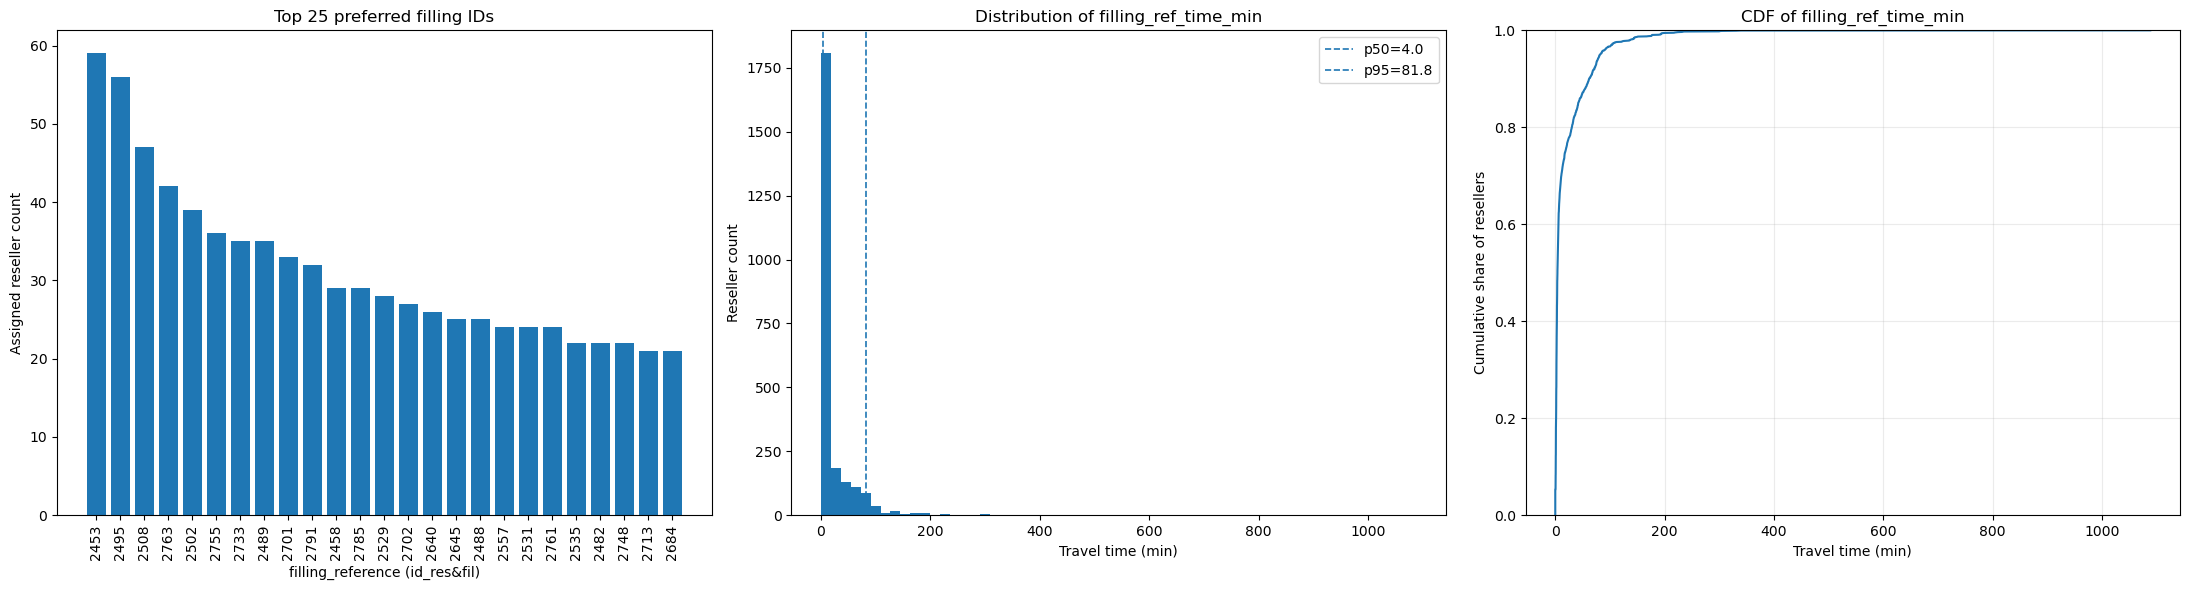


=== QUICK SANITY FLAGS ===
Coverage >= 95%? YES
p95 <= 120 min? YES
p99 <= 240 min? YES


In [5]:
"""
Distribution diagnostics for reseller filling assignment.

This cell is independent and can be run after Cells 1-3.
It checks:
- coverage of valid assignment (existing filling_reference + valid travel time),
- distribution of preferred filling IDs,
- distribution of travel times.
"""

from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("dataset_big")
WORK_GPKG = DATA_DIR / "chain_with_cost.gpkg"
RESELL_LAYER = "resell"
FILLING_LAYER = "filling"
ID_COL = "id_res&fil"
FILL_REF_COL = "filling_reference"
FILL_TIME_COL = "filling_ref_time_min"

print("[1/4] Loading reseller/filling layers...")
resell = gpd.read_file(WORK_GPKG, layer=RESELL_LAYER)
filling = gpd.read_file(WORK_GPKG, layer=FILLING_LAYER)
if resell.empty:
    raise RuntimeError("Resell layer is empty.")
if filling.empty:
    raise RuntimeError("Filling layer is empty.")

for c in [ID_COL, FILL_REF_COL, FILL_TIME_COL]:
    if c not in resell.columns:
        raise KeyError(f"Missing column '{c}' in layer '{RESELL_LAYER}'.")
if ID_COL not in filling.columns:
    raise KeyError(f"Missing column '{ID_COL}' in layer '{FILLING_LAYER}'.")

print("[2/4] Building validity flags...")
res_ref = pd.to_numeric(resell[FILL_REF_COL], errors="coerce")
res_tmin = pd.to_numeric(resell[FILL_TIME_COL], errors="coerce")
fill_ids = pd.to_numeric(filling[ID_COL], errors="coerce")

fill_id_set = set(fill_ids[np.isfinite(fill_ids)].astype(np.int64).tolist())
ref_finite = np.isfinite(res_ref)
ref_positive = ref_finite & (res_ref > 0)
ref_exists = ref_positive & pd.Series(res_ref.astype("Int64")).isin(fill_id_set).to_numpy()
time_valid = np.isfinite(res_tmin) & (res_tmin >= 0) & (res_tmin < 7000)
assigned_valid = ref_exists & time_valid

n_total = len(resell)
n_assigned = int(assigned_valid.sum())
assignment_rate = n_assigned / n_total if n_total > 0 else np.nan

print("=== ASSIGNMENT COVERAGE ===")
print(f"Total resellers                      : {n_total:,}")
print(f"Valid assigned resellers             : {n_assigned:,}")
print(f"Assignment coverage                  : {assignment_rate:.2%}")
print(f"Missing/invalid filling reference    : {int((~ref_exists).sum()):,}")
print(f"Invalid/unassigned travel time       : {int((~time_valid).sum()):,}")

if n_assigned == 0:
    raise RuntimeError("No valid assignments found: cannot build distribution plots.")

print("[3/4] Computing distributions...")
assigned_ref = res_ref[assigned_valid].astype(np.int64)
assigned_tmin = res_tmin[assigned_valid].astype(float)

id_counts = assigned_ref.value_counts().sort_values(ascending=False)
top_n = 25
top_counts = id_counts.head(top_n)

q50 = float(np.nanmedian(assigned_tmin))
q90 = float(np.nanpercentile(assigned_tmin, 90))
q95 = float(np.nanpercentile(assigned_tmin, 95))
q99 = float(np.nanpercentile(assigned_tmin, 99))
print("=== TRAVEL TIME STATS (min) ===")
print(f"min / p50 / p90 / p95 / p99 / max: {float(np.nanmin(assigned_tmin)):.2f} / {q50:.2f} / {q90:.2f} / {q95:.2f} / {q99:.2f} / {float(np.nanmax(assigned_tmin)):.2f}")

print("=== TOP PREFERRED FILLING IDs ===")
print(top_counts.to_string())

print("[4/4] Plotting distributions...")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: top preferred filling IDs
axes[0].bar(top_counts.index.astype(str), top_counts.values)
axes[0].set_title(f"Top {top_n} preferred filling IDs")
axes[0].set_xlabel("filling_reference (id_res&fil)")
axes[0].set_ylabel("Assigned reseller count")
axes[0].tick_params(axis="x", rotation=90)

# Plot 2: travel time histogram
axes[1].hist(assigned_tmin, bins=60)
axes[1].set_title("Distribution of filling_ref_time_min")
axes[1].set_xlabel("Travel time (min)")
axes[1].set_ylabel("Reseller count")
axes[1].axvline(q50, linestyle="--", linewidth=1.2, label=f"p50={q50:.1f}")
axes[1].axvline(q95, linestyle="--", linewidth=1.2, label=f"p95={q95:.1f}")
axes[1].legend()

# Plot 3: cumulative distribution (CDF)
sorted_t = np.sort(assigned_tmin)
cdf = np.arange(1, len(sorted_t) + 1) / len(sorted_t)
axes[2].plot(sorted_t, cdf)
axes[2].set_title("CDF of filling_ref_time_min")
axes[2].set_xlabel("Travel time (min)")
axes[2].set_ylabel("Cumulative share of resellers")
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.25)

fig.tight_layout()
plt.show()

# Quick reasonableness flags
print("\n=== QUICK SANITY FLAGS ===")
print(f"Coverage >= 95%? {'YES' if assignment_rate >= 0.95 else 'NO'}")
print(f"p95 <= 120 min? {'YES' if q95 <= 120 else 'NO'}")
print(f"p99 <= 240 min? {'YES' if q99 <= 240 else 'NO'}")

In [4]:
"""
Build filling_point_clients from 4.3 output + 4.4 reseller->filling linkage.

Simplified approach:
- filling base points are taken directly from 4.4 (chain_with_cost.gpkg, layer=filling)
- local client metrics are attached from 4.3 (sell_point_clients) by id_res&fil
- totals per filling are computed by aggregating all 4.3 points assigned to that filling_reference
- final totals are compared against global 4.3 sums (clients and clients_max_ideal)
"""

from __future__ import annotations

from pathlib import Path

import geopandas as gpd
import pandas as pd

DATA_DIR = Path("dataset_big")
SELL_POINT_GPKG = DATA_DIR / "sell_point_clients.gpkg"
SELL_POINT_LAYER = "sell_point_clients"
CHAIN_GPKG = DATA_DIR / "chain_with_cost.gpkg"
RESELL_LAYER = "resell"
FILLING_LAYER = "filling"
OUTPUT_GPKG = DATA_DIR / "filling_point_clients.gpkg"
OUTPUT_LAYER = "filling_point_clients"

ID_COL = "id_res&fil"
FILL_REF_COL = "filling_reference"

CLIENT_COLS = [
    "clients_walk",
    "clients_max_ideal_walk",
    "clients_car",
    "clients_max_ideal_car",
    "clients",
    "clients_max_ideal",
]

print("[1/7] Loading filling base from 4.4...")
filling_44 = gpd.read_file(CHAIN_GPKG, layer=FILLING_LAYER)
if filling_44.empty:
    raise RuntimeError(f"Layer '{FILLING_LAYER}' is empty in {CHAIN_GPKG}")
if ID_COL not in filling_44.columns:
    raise KeyError(f"Missing '{ID_COL}' in layer '{FILLING_LAYER}' of {CHAIN_GPKG}")

filling_44[ID_COL] = pd.to_numeric(filling_44[ID_COL], errors="coerce")
filling_44 = filling_44[filling_44[ID_COL].notna() & (filling_44[ID_COL] > 0)].copy()
filling_44[ID_COL] = filling_44[ID_COL].astype("int64")
if filling_44.empty:
    raise RuntimeError("No valid filling IDs found in 4.4 filling layer.")

filling_base_cols = [c for c in [ID_COL, "place_id", "lat", "lon", "geometry"] if c in filling_44.columns]
filling_base = filling_44[filling_base_cols].copy()
filling_id_set = set(filling_base[ID_COL].tolist())
print(f"Filling points in 4.4: {len(filling_base):,}")

print("[2/7] Loading sell_point_clients from 4.3...")
sell_points = gpd.read_file(SELL_POINT_GPKG, layer=SELL_POINT_LAYER)
if sell_points.empty:
    raise RuntimeError(f"Layer '{SELL_POINT_LAYER}' is empty in {SELL_POINT_GPKG}")

required = [ID_COL] + CLIENT_COLS
missing = [c for c in required if c not in sell_points.columns]
if missing:
    raise KeyError(f"Missing required column(s) in sell_point_clients: {missing}")

sell_points[ID_COL] = pd.to_numeric(sell_points[ID_COL], errors="coerce")
sell_points = sell_points[sell_points[ID_COL].notna() & (sell_points[ID_COL] > 0)].copy()
sell_points[ID_COL] = sell_points[ID_COL].astype("int64")
for c in CLIENT_COLS:
    sell_points[c] = pd.to_numeric(sell_points[c], errors="coerce").fillna(0.0).astype(float)

print("[3/7] Attaching local filling metrics from 4.3 by id_res&fil...")
marker_candidates = ["id_filling_only", "id_fillingonly", "id_fillingOnly"]
marker_col = next((c for c in marker_candidates if c in sell_points.columns), None)

local_cols = [ID_COL] + CLIENT_COLS
for c in ["place_id", "lat", "lon"]:
    if c in sell_points.columns and c not in local_cols:
        local_cols.append(c)
if marker_col is not None and marker_col not in local_cols:
    local_cols.append(marker_col)

local_metrics = sell_points[local_cols].copy()
local_metrics = local_metrics.drop_duplicates(subset=[ID_COL], keep="first")

out = filling_base.merge(local_metrics, on=ID_COL, how="left", suffixes=("", "_sp"))
for c in CLIENT_COLS:
    out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0.0).astype(float)
if marker_col is None:
    out["id_filling_only"] = pd.NA
    marker_col = "id_filling_only"

print("[4/7] Aggregating all assigned reseller clients per filling...")
resell_44 = gpd.read_file(CHAIN_GPKG, layer=RESELL_LAYER)
for c in [ID_COL, FILL_REF_COL]:
    if c not in resell_44.columns:
        raise KeyError(f"Missing '{c}' in layer '{RESELL_LAYER}' of {CHAIN_GPKG}")

res_assign = resell_44[[ID_COL, FILL_REF_COL]].copy()
res_assign[ID_COL] = pd.to_numeric(res_assign[ID_COL], errors="coerce")
res_assign[FILL_REF_COL] = pd.to_numeric(res_assign[FILL_REF_COL], errors="coerce")
res_assign = res_assign[
    res_assign[ID_COL].notna()
    & res_assign[FILL_REF_COL].notna()
    & (res_assign[ID_COL] > 0)
    & (res_assign[FILL_REF_COL] > 0)
]
res_assign[ID_COL] = res_assign[ID_COL].astype("int64")
res_assign[FILL_REF_COL] = res_assign[FILL_REF_COL].astype("int64")
res_assign = res_assign[res_assign[FILL_REF_COL].isin(filling_id_set)].copy()

point_clients = sell_points[[ID_COL, "clients", "clients_max_ideal"]].copy()
assigned = res_assign.merge(point_clients, on=ID_COL, how="left")
assigned["clients"] = pd.to_numeric(assigned["clients"], errors="coerce").fillna(0.0).astype(float)
assigned["clients_max_ideal"] = pd.to_numeric(assigned["clients_max_ideal"], errors="coerce").fillna(0.0).astype(float)

agg = (
    assigned.groupby(FILL_REF_COL, as_index=False)[["clients", "clients_max_ideal"]]
    .sum()
    .rename(
        columns={
            FILL_REF_COL: ID_COL,
            "clients": "assigned_fil_clients",
            "clients_max_ideal": "assigned_fil_max_ideal_clients",
        }
    )
)

print("[5/7] Building final filling table...")
out = out.merge(agg, on=ID_COL, how="left")
out["assigned_fil_clients"] = pd.to_numeric(out["assigned_fil_clients"], errors="coerce").fillna(0.0).astype(float)
out["assigned_fil_max_ideal_clients"] = pd.to_numeric(out["assigned_fil_max_ideal_clients"], errors="coerce").fillna(0.0).astype(float)

# Include local filling clients + assigned reseller clients
out["total_fil_clients"] = out["clients"].astype(float) + out["assigned_fil_clients"]
out["total_max_ideal_clients"] = out["clients_max_ideal"].astype(float) + out["assigned_fil_max_ideal_clients"]

keep_cols = [
    ID_COL,
    marker_col,
    "place_id",
    "lat",
    "lon",
    "clients_walk",
    "clients_max_ideal_walk",
    "clients_car",
    "clients_max_ideal_car",
    "clients",
    "clients_max_ideal",
    "total_fil_clients",
    "total_max_ideal_clients",
    "geometry",
]
keep_cols = [c for c in keep_cols if c in out.columns]
out = out[keep_cols].copy()
out = gpd.GeoDataFrame(out, geometry="geometry", crs=filling_44.crs)

print("[6/7] Totals check vs 4.3 output...")
sum_43_clients = float(sell_points["clients"].sum())
sum_43_max = float(sell_points["clients_max_ideal"].sum())
sum_fill_clients = float(out["total_fil_clients"].sum())
sum_fill_max = float(out["total_max_ideal_clients"].sum())

diff_clients = sum_fill_clients - sum_43_clients
diff_max = sum_fill_max - sum_43_max

print("=== TOTALS COMPARISON (4.4 filling aggregation vs 4.3 sell_point_clients) ===")
print(f"4.3 total clients             : {sum_43_clients:,.2f}")
print(f"4.4 filling total_fil_clients : {sum_fill_clients:,.2f}")
print(f"Difference                    : {diff_clients:+,.6f}")
print(f"4.3 total clients_max_ideal             : {sum_43_max:,.2f}")
print(f"4.4 filling total_max_ideal_clients     : {sum_fill_max:,.2f}")
print(f"Difference                               : {diff_max:+,.6f}")

tol = 1e-6
if abs(diff_clients) <= tol and abs(diff_max) <= tol:
    print("Check result: OK (totals match)")
else:
    print(
        "Check result: WARNING (totals differ). "
        "Possible causes: points without valid filling_reference or IDs not aligned across steps."
    )

print("[7/7] Writing filling_point_clients output...")
out.to_file(OUTPUT_GPKG, layer=OUTPUT_LAYER, driver="GPKG")
print(f"Saved: {OUTPUT_GPKG} | layer={OUTPUT_LAYER}")
print(f"Filling rows written: {len(out):,}")

[1/7] Loading filling base from 4.4...
Filling points in 4.4: 376
[2/7] Loading sell_point_clients from 4.3...
[3/7] Attaching local filling metrics from 4.3 by id_res&fil...
[4/7] Aggregating all assigned reseller clients per filling...
[5/7] Building final filling table...
[6/7] Totals check vs 4.3 output...
=== TOTALS COMPARISON (4.4 filling aggregation vs 4.3 sell_point_clients) ===
4.3 total clients             : 26,432,109.99
4.4 filling total_fil_clients : 26,432,109.99
Difference                    : +0.000000
4.3 total clients_max_ideal             : 204,794,305.36
4.4 filling total_max_ideal_clients     : 204,794,305.36
Difference                               : +0.000000
Check result: OK (totals match)
[7/7] Writing filling_point_clients output...
Saved: dataset_big\filling_point_clients.gpkg | layer=filling_point_clients
Filling rows written: 376
